In [48]:
from google.colab import files

uploaded = files.upload()

Saving historical_data.csv to historical_data (1).csv


In [49]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv


In [50]:
import os
print(os.listdir())

['.config', 'historical_data.csv', 'historical_data (1).csv', 'fear_greed_index (1).csv', 'fear_greed_index.csv', 'sample_data']


In [51]:
import pandas as pd

trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

In [52]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [53]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [54]:
print("Trades Columns:")
print(trades.columns)

print("\nSentiment Columns:")
print(sentiment.columns)

Trades Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Sentiment Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [55]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [56]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [57]:
#Data Cleaning
#Check missing values:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [58]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [59]:
#Check duplicates:
print(trades.duplicated().sum())

0


In [60]:
print(sentiment.duplicated().sum())

0


In [61]:
#remove duplicates
trades.drop_duplicates(inplace=True)
sentiment.drop_duplicates(inplace=True)

In [62]:
#date conversion
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [63]:
trades['date'] = trades['Timestamp IST'].dt.date

In [64]:
sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [65]:
#merge data sets
merged = pd.merge(
    trades,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [66]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [67]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [68]:
#Analysis
#Profit Analysis
profit_analysis = merged.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count','mean','sum']
)

profit_analysis

,count,mean,sum
classification,,,
Extreme Fear,21400,34.537862,7.391102e+05
Extreme Greed,39992,67.892861,2.715171e+06
Fear,61837,54.290400,3.357155e+06
Greed,50303,42.743559,2.150129e+06
Neutral,37686,34.307718,1.292921e+06


In [69]:
#trading volume
volume_analysis = merged.groupby(
    'classification'
)['Size USD'].sum()

volume_analysis

,Size USD
classification,
Extreme Fear,1.144843e+08
Extreme Greed,1.244652e+08
Fear,4.833248e+08
Greed,2.885825e+08
Neutral,1.802421e+08


In [70]:
#win rate
merged['Win'] = merged['Closed PnL'] > 0

In [71]:
win_rate = merged.groupby(
    'classification'
)['Win'].mean()*100

win_rate

,Win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


In [72]:
#fees
fee_analysis = merged.groupby(
    'classification'
)['Fee'].mean()

fee_analysis

,Fee
classification,
Extreme Fear,1.116291
Extreme Greed,0.675902
Fear,1.495172
Greed,1.254372
Neutral,1.044798


In [73]:
#top coins
top_coins = merged.groupby(
    'Coin'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

top_coins

,Closed PnL
Coin,
@107,2.783913e+06
HYPE,1.948485e+06
SOL,1.639556e+06
ETH,1.319979e+06
BTC,8.680447e+05
MELANIA,3.903511e+05
ENA,2.173295e+05
SUI,1.992688e+05
ZRO,1.837778e+05


In [74]:
#top traders
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

top_traders

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


In [75]:
import matplotlib.pyplot as plt

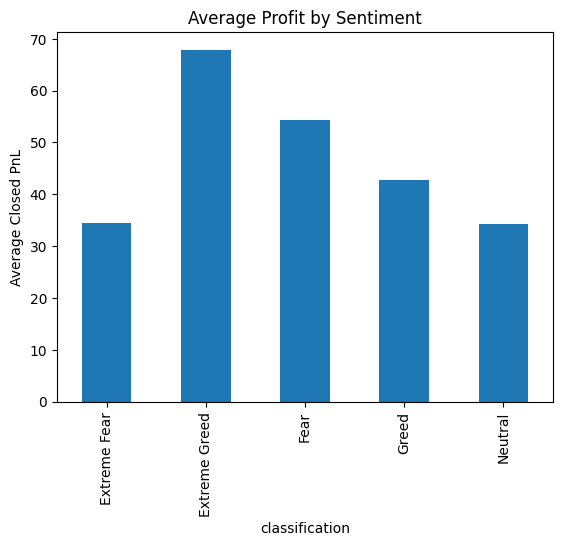

In [76]:
merged.groupby(
    'classification'
)['Closed PnL'].mean().plot(
    kind='bar'
)

plt.title("Average Profit by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

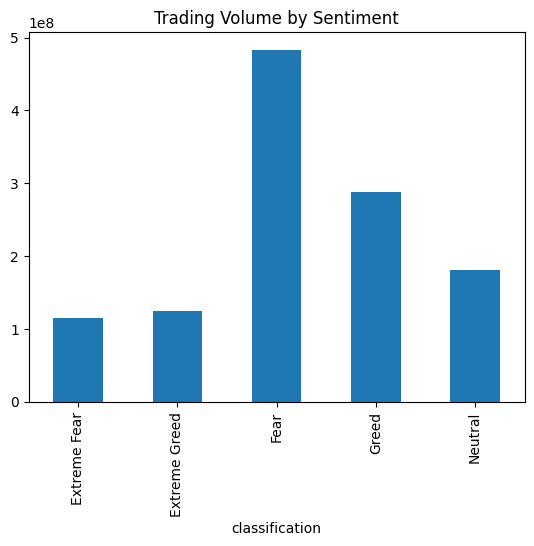

In [77]:
#volume chart
volume_analysis.plot(kind='bar')

plt.title("Trading Volume by Sentiment")
plt.show()

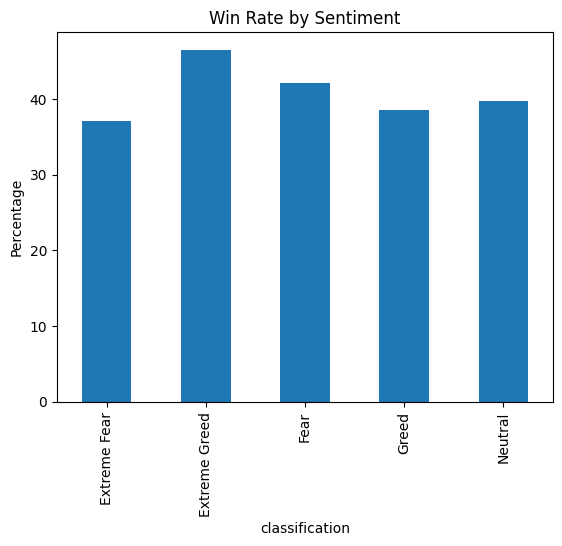

In [78]:
#win rate chart
win_rate.plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.ylabel("Percentage")
plt.show()

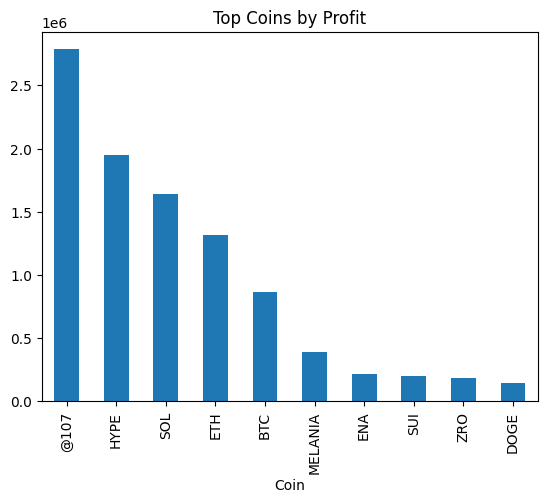

In [79]:
#top coin chart
top_coins.plot(kind='bar')

plt.title("Top Coins by Profit")
plt.show()

In [80]:
profit_analysis

,count,mean,sum
classification,,,
Extreme Fear,21400,34.537862,7.391102e+05
Extreme Greed,39992,67.892861,2.715171e+06
Fear,61837,54.290400,3.357155e+06
Greed,50303,42.743559,2.150129e+06
Neutral,37686,34.307718,1.292921e+06


<b> Profit Analysis</b>

Extreme Greed sentiment showed the highest average profit of 67.89. This means traders earned more profit when the market was very optimistic.

Fear sentiment had the second-highest average profit of 54.29. Extreme Fear and Neutral sentiment had lower average profits compared to other sentiment categories.

This suggests that market sentiment has an impact on trader profitability, and traders tended to perform better during Extreme Greed periods.


In [81]:
win_rate

,Win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


<b> Win Rate Analysis</b>

Extreme Greed sentiment had the highest win rate of 46.49%, which means traders were more likely to make profitable trades during periods of strong market optimism.

Fear sentiment had the second-highest win rate of 42.08%, while Extreme Fear had the lowest win rate of 37.06%.

These results suggest that trader success was generally higher during positive market sentiment conditions.


In [82]:
volume_analysis

,Size USD
classification,
Extreme Fear,1.144843e+08
Extreme Greed,1.244652e+08
Fear,4.833248e+08
Greed,2.885825e+08
Neutral,1.802421e+08


<b> Trading Volume Analysis</b>

Fear sentiment recorded the highest trading volume, with a total trading volume of approximately 483.32 million USD.

This indicates that traders were most active during Fear periods. Greed sentiment also showed significant trading activity, while Extreme Fear and Extreme Greed had comparatively lower trading volumes.

The results suggest that market uncertainty and fear may encourage higher trading activity among traders

In [83]:
top_coins.head()

,Closed PnL
Coin,
@107,2.783913e+06
HYPE,1.948485e+06
SOL,1.639556e+06
ETH,1.319979e+06
BTC,8.680447e+05


<b>Top Coins Analysis</b>

The most profitable coin was **@107**, generating a total Closed PnL of approximately 2.78 million.

Other highly profitable coins included **HYPE**, **SOL**, **ETH**, and **BTC**.

This indicates that these assets contributed the most to trader profitability during the analysis period, with @107 outperforming all other coins in terms of total profit generated.


In [84]:
top_traders.head()

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05


<b> Top Traders Analysis</b>

The most profitable trader was **0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23**, generating a total profit of approximately 2.14 million.

Other top-performing traders also achieved significant profits, with total profits ranging from 0.84 million to 1.60 million.

This suggests that a small group of traders consistently generated substantial profits and outperformed the broader trading population.


<b> Recommendations</b>

1. Market sentiment should be considered before making trading decisions.
2. Extreme Greed periods showed the highest average profit and win rate, indicating favorable trading conditions.
3. Fear periods recorded the highest trading volume, suggesting increased market participation during uncertain conditions.
4. Traders should combine sentiment analysis with risk management techniques to improve decision-making.
5. Monitoring top-performing assets and trader behavior can help identify profitable opportunities.


<b> Conclusion</b>

This analysis explored the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Fear & Greed Index.

The results showed that Extreme Greed sentiment produced the highest average profit and win rate, while Fear sentiment generated the highest trading volume. The most profitable coin was @107, and several traders consistently achieved strong profits across market conditions.

These findings suggest that market sentiment influences trader behavior and performance. Incorporating sentiment indicators into trading strategies may help traders make more informed decisions and manage risk more effectively.
